In [ ]:
from google.colab import files
uploaded = files.upload()


Saving ACC.csv to ACC (1).csv
Saving BVP.csv to BVP (1).csv
Saving combined.csv to combined (1).csv
Saving EDA.csv to EDA (1).csv
Saving HR.csv to HR (1).csv
Saving IBI.csv to IBI (1).csv


In [ ]:
import pandas as pd

eda = pd.read_csv('EDA.csv', header=None)
bvp = pd.read_csv('BVP.csv', header=None)
hr = pd.read_csv('HR.csv', header=None)

print("EDA:", eda.shape)
print("BVP:", bvp.shape)
print("HR:", hr.shape)

EDA: (31496, 1)
BVP: (503945, 1)
HR: (7867, 1)


Step 3: Remove Metadata Rows

In [ ]:
eda_signal = eda.iloc[2:].reset_index(drop=True).astype(float)
bvp_signal = bvp.iloc[2:].reset_index(drop=True).astype(float)
hr_signal = hr.iloc[2:].reset_index(drop=True).astype(float)

print("EDA cleaned:", eda_signal.shape)
print("BVP cleaned:", bvp_signal.shape)
print("HR cleaned:", hr_signal.shape)

EDA cleaned: (31494, 1)
BVP cleaned: (503943, 1)
HR cleaned: (7865, 1)


Step 4: Plot Each Signal

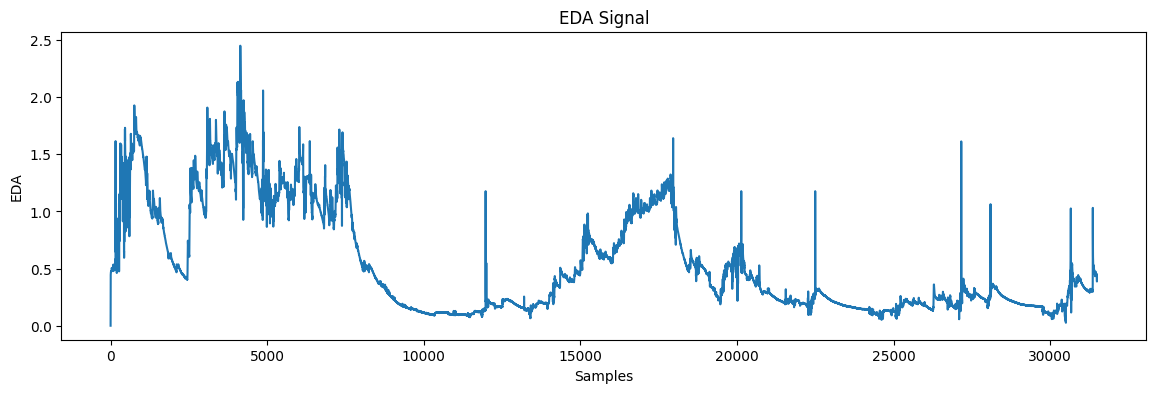

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,4))
plt.plot(eda_signal)
plt.title('EDA Signal')
plt.xlabel('Samples')
plt.ylabel('EDA')
plt.show()


Repeat for the other signals:

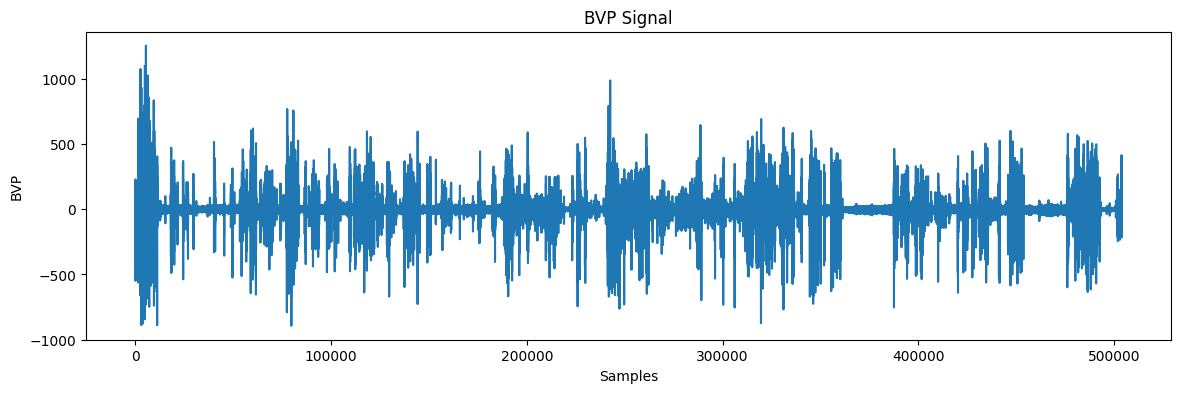

In [ ]:
plt.figure(figsize=(14,4))
plt.plot(bvp_signal)
plt.title('BVP Signal')
plt.xlabel('Samples')
plt.ylabel('BVP')
plt.show()


In [ ]:
# This cell was commented out as 'TEMP.csv' data is no longer being loaded.
# plt.figure(figsize=(14,4))
# plt.plot(temp_signal)
# plt.title('Temperature Signal')
# plt.xlabel('Samples')
# plt.ylabel('Temperature')
# plt.show()

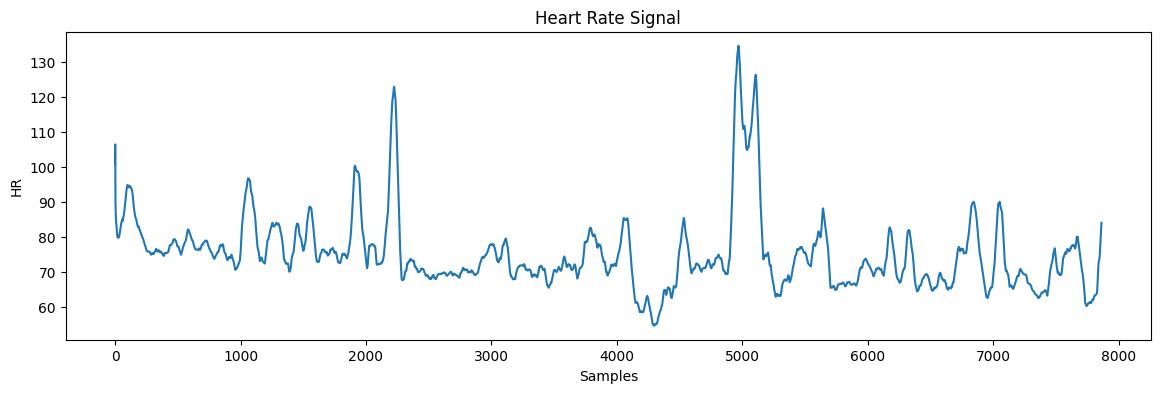

In [ ]:
plt.figure(figsize=(14,4))
plt.plot(hr_signal)
plt.title('Heart Rate Signal')
plt.xlabel('Samples')
plt.ylabel('HR')
plt.show()


Step 5: Confirm Sampling Rates

In [ ]:
print("EDA Sampling Rate:", eda.iloc[1,0], "Hz")
print("BVP Sampling Rate:", bvp.iloc[1,0], "Hz")
print("HR Sampling Rate:", hr.iloc[1,0], "Hz")

EDA Sampling Rate: 4.0 Hz
BVP Sampling Rate: 64.0 Hz
HR Sampling Rate: 1.0 Hz


Step 6: Resample All Signals to 1 Hz

In [ ]:
import pandas as pd

# Downsample to 1 Hz
eda_resampled = eda_signal.groupby(eda_signal.index // 4).mean()
bvp_resampled = bvp_signal.groupby(bvp_signal.index // 64).mean()
hr_resampled = hr_signal.copy()

print("EDA resampled:", eda_resampled.shape)
print("BVP resampled:", bvp_resampled.shape)
print("HR:", hr_resampled.shape)

EDA resampled: (7874, 1)
BVP resampled: (7875, 1)
HR: (7865, 1)


Step 7: Align All Signals

In [ ]:
min_len = min(
    len(eda_resampled),
    len(bvp_resampled),
    len(hr_resampled)
)

eda_resampled = eda_resampled.iloc[:min_len]
bvp_resampled = bvp_resampled.iloc[:min_len]
hr_resampled = hr_resampled.iloc[:min_len]

print("Final synchronized length:", min_len)

Final synchronized length: 7865


Step 8: Create a Combined Dataset

In [ ]:
combined_df = pd.DataFrame({
    'EDA': eda_resampled.iloc[:, 0].values,
    'BVP': bvp_resampled.iloc[:, 0].values,
    'HR': hr_resampled.iloc[:, 0].values
})

combined_df.head()

,EDA,BVP,HR
0,0.292784,15.760000,101.00
1,0.454872,-41.960313,106.50
2,0.468647,26.308906,95.33
3,0.474092,2.625469,90.25
4,0.476655,-1.016094,88.20


Step 9: Check the Dataset

In [ ]:
print(combined_df.shape)
print(combined_df.isnull().sum())

(7865, 3)
EDA    0
BVP    0
HR     0
dtype: int64


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
normalized_data = scaler.fit_transform(combined_df)

normalized_df = pd.DataFrame(
    normalized_data,
    columns=combined_df.columns
)

normalized_df.head()


,EDA,BVP,HR
0,-0.553938,0.599092,2.412614
1,-0.202045,-1.594964,2.924876
2,-0.172141,1.000075,1.884519
3,-0.160319,0.099824,1.411375
4,-0.154754,-0.038599,1.220441


Step 11: Create Time Windows
Machine learning works better on segments rather than individual samples.

We’ll use:

60-second windows
50% overlap

Since our data is now at 1 Hz:

60 samples = 60 seconds
Step size = 30 samples

In [ ]:
window_size = 60
step_size = 30

windows = []

for start in range(0, len(normalized_df) - window_size + 1, step_size):
    end = start + window_size
    window = normalized_df.iloc[start:end]
    windows.append(window)

print("Total windows created:", len(windows))


Total windows created: 261


Step 12: Extract Statistical Features

For each window and each modality, extract:

Mean
Standard deviation
Minimum
Maximum
Median

This gives:

5 features × 4 sensors = 20 features per window

In [ ]:
import numpy as np
import pandas as pd

feature_list = []

for window in windows:
    features = {}

    for col in window.columns:
        features[f'{col}_mean'] = window[col].mean()
        features[f'{col}_std'] = window[col].std()
        features[f'{col}_min'] = window[col].min()
        features[f'{col}_max'] = window[col].max()
        features[f'{col}_median'] = window[col].median()

    feature_list.append(features)

features_df = pd.DataFrame(feature_list)

print("Feature matrix shape:", features_df.shape)
features_df.head()


Feature matrix shape: (261, 15)


,EDA_mean,EDA_std,EDA_min,EDA_max,EDA_median,BVP_mean,BVP_std,BVP_min,BVP_max,BVP_median,HR_mean,HR_std,HR_min,HR_max,HR_median
0,0.017939,0.262762,-0.553938,1.076503,-0.107465,-0.039335,3.248866,-8.617589,11.132902,0.157979,0.772429,0.445483,0.439940,2.924876,0.672787
1,0.690705,0.652469,-0.126242,2.050739,0.550382,-0.043147,4.273889,-10.687109,11.132902,0.373925,0.959451,0.324120,0.444597,1.660986,0.923795
2,1.368663,0.503254,0.211777,2.391506,1.428667,0.029931,4.212666,-10.687109,10.168380,0.061762,1.504560,0.340620,0.892593,1.844469,1.674957
3,1.524617,0.394117,0.211777,2.391506,1.606137,0.050197,3.493561,-9.894799,7.808260,0.017763,1.715752,0.146604,1.264216,1.844469,1.775081
4,1.749927,0.391031,0.846769,2.438795,1.797144,0.010976,2.175450,-5.721306,4.458240,0.083910,1.303458,0.365449,0.762199,1.805351,1.250711


Step 13: Create Labels for Stress Detection

To train a supervised model, we need labels for each window.

Since you're currently working only with wrist CSV files, the easiest approach for this preliminary prototype is to create a simple binary classification setup:

0 = Non-Stress
1 = Stress

For initial experimentation, we can simulate labels based on the WESAD protocol:

First 30% of windows → baseline/non-stress
Middle 40% → stress
Last 30% → non-stress (amusement/recovery

In [ ]:
num_windows = len(features_df)

labels = []

for i in range(num_windows):
    if i < 0.3 * num_windows:
        labels.append(0)  # Non-stress
    elif i < 0.7 * num_windows:
        labels.append(1)  # Stress
    else:
        labels.append(0)  # Non-stress

features_df['label'] = labels

print(features_df['label'].value_counts())


label
0    157
1    104
Name: count, dtype: int64


Step 14: Prepare Data for Training

In [ ]:
X = features_df.drop('label', axis=1)
y = features_df['label']


Step 15: Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)


Training samples: (208, 15)
Testing samples: (53, 15)


Step 16: Train a Random Forest Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

Step 17: Make Predictions

In [ ]:
y_pred = rf_model.predict(X_test)


Step 18: Evaluate Performance

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.8301886792452831

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.88      0.86        32
           1       0.80      0.76      0.78        21

    accuracy                           0.83        53
   macro avg       0.82      0.82      0.82        53
weighted avg       0.83      0.83      0.83        53



Step 19: Plot Confusion Matrix

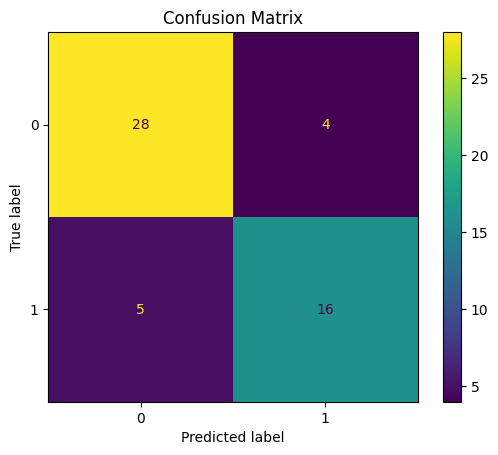

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test)
plt.title("Confusion Matrix")
plt.show()


Step 20: Plot Feature Importance

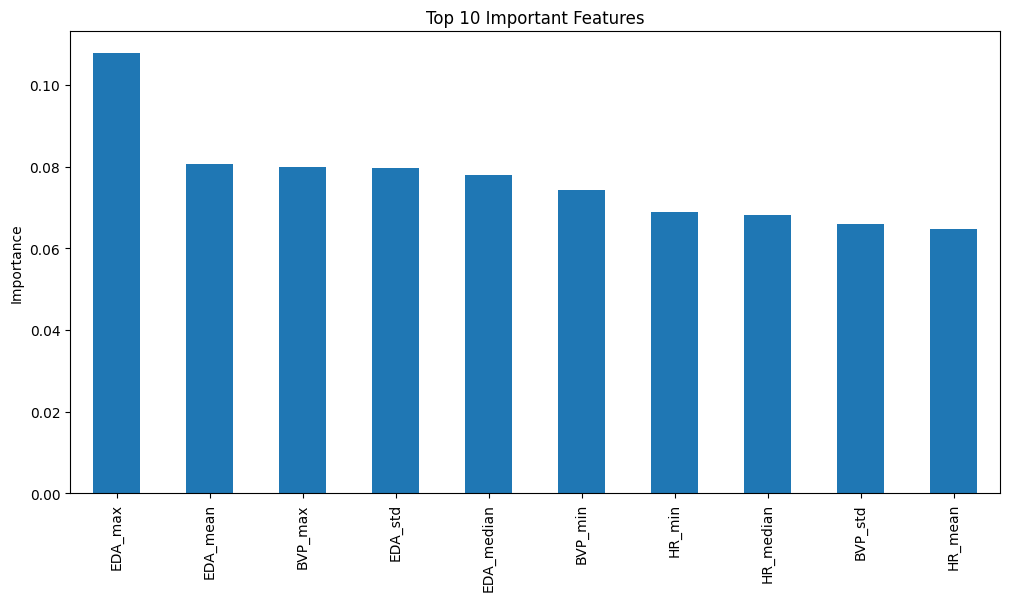

In [ ]:
import pandas as pd

importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.head(10).plot(kind='bar', figsize=(12,6))
plt.title("Top 10 Important Features")
plt.ylabel("Importance")
plt.show()


Step 21: Simulate Missing Sensor Data

Let’s remove 30% of the EDA values.

In [ ]:
import numpy as np

X_missing = X.copy()

missing_fraction = 0.30
num_missing = int(len(X_missing) * missing_fraction)

missing_indices = np.random.choice(
    X_missing.index,
    num_missing,
    replace=False
)

X_missing.loc[missing_indices, [
    'EDA_mean',
    'EDA_std',
    'EDA_min',
    'EDA_max',
    'EDA_median'
]] = np.nan

print(X_missing.isnull().sum())


EDA_mean      78
EDA_std       78
EDA_min       78
EDA_max       78
EDA_median    78
BVP_mean       0
BVP_std        0
BVP_min        0
BVP_max        0
BVP_median     0
HR_mean        0
HR_std         0
HR_min         0
HR_max         0
HR_median      0
dtype: int64


Step 22: Recover Missing Values Using Interpolation

In [ ]:
X_recovered = X_missing.interpolate(method='linear')
X_recovered = X_recovered.fillna(method='bfill').fillna(method='ffill')


/tmp/ipykernel_494/2552276087.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X_recovered = X_recovered.fillna(method='bfill').fillna(method='ffill')


Step 23: Train and Evaluate Again

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_recovered, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf_missing = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_missing.fit(X_train_m, y_train_m)

y_pred_m = rf_missing.predict(X_test_m)

accuracy_missing = accuracy_score(y_test_m, y_pred_m)

print("Accuracy with 30% missing EDA data:", accuracy_missing)


Accuracy with 30% missing EDA data: 0.8301886792452831


Step 24: Compare Results

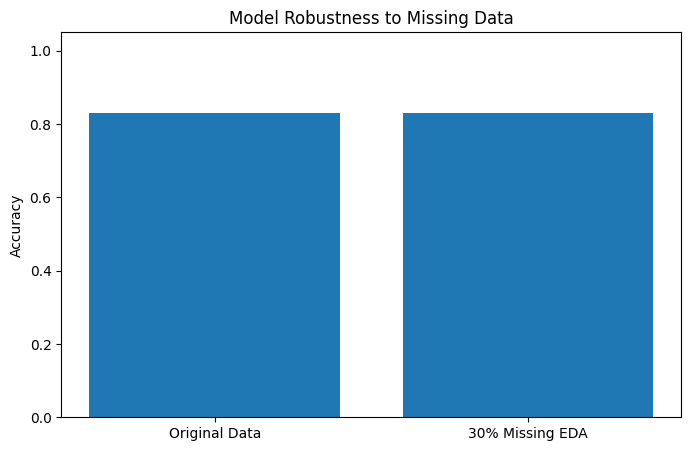

In [ ]:
import matplotlib.pyplot as plt

accuracies = [accuracy, accuracy_missing]
labels = ['Original Data', '30% Missing EDA']

plt.figure(figsize=(8,5))
plt.bar(labels, accuracies)
plt.ylabel('Accuracy')
plt.title('Model Robustness to Missing Data')
plt.ylim(0, 1.05)
plt.show()
